# CROCO Idealized Run — Wind-Driven Double Gyre (real model output)

**Runnable companion to [`croco-model-guide.md`](../croco-model-guide.md) §17a
(Idealized test case).**

`BASIN` is CROCO's classic idealized case: a flat, closed rectangular basin
forced by a double-gyre wind stress. With no external data it spins up the
textbook **wind-driven double gyre** — a subpolar and a subtropical circulation
cell with a western boundary current between them. This notebook plots **real
output** from an actual CROCO run (gfortran / conda toolchain).

```bash
# Set up a clean configuration (this stages all paths correctly):
./create_config.bash -n basin_cfg -o "oce-dev test_cases" -s <croco_src> ...
cd basin_cfg
# select the case in cppdefs.h:  #undef REGIONAL / #define BASIN
./jobcomp                                   # → croco executable
cp TEST_CASES/croco.in.Basin croco.in
LC_ALL=C ./croco croco.in                   # → "MAIN: DONE", basin_his.nc
```

> **Lessons from building CROCO on a fresh box:** use `create_config.bash`
> (raw in-tree `jobcomp` mis-stages the optional STOGEN/PISCES sources); build
> `jobcomp`'s make with `gmake -r` (Fortran `.mod` files trip gmake's built-in
> Modula-2 rule); and run with `LC_ALL=C` (a comma-decimal locale breaks
> list-directed reads). Note CROCO reads its input as an **argument**
> (`./croco croco.in`) — unlike ROMS, which uses stdin.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from meteo_examples import sampledata

ds = xr.open_dataset(sampledata.croco_basin_path())
x, y = ds["x_km"].values, ds["y_km"].values
days = ds["time_days"].values
plt.rcParams["figure.dpi"] = 110
print(ds.attrs["title"])
print(f"{len(days)} frames; basin {x[-1]:.0f} x {y[-1]:.0f} km")

Compact real CROCO BASIN output (wind-driven double gyre)
37 frames; basin 3630 x 2828 km


## 1 · The double gyre in sea-surface height

The free surface `zeta` is the clearest view of the circulation: a positive dome
(subtropical gyre) and a negative low (subpolar gyre), separated by a sharp
front — the western boundary current intensifies on the left wall.

SSH range: -11.3 … 11.3 cm


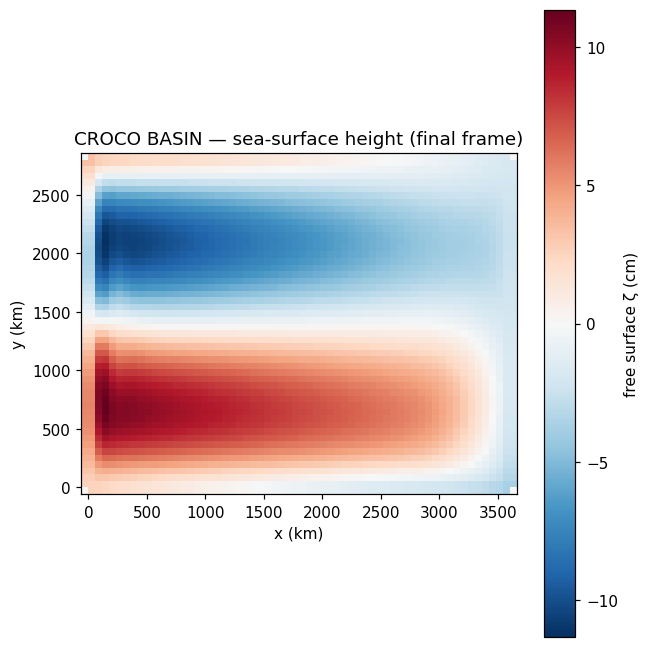

In [2]:
zeta = ds["zeta"].isel(time=-1).values * 100        # cm
fig, ax = plt.subplots(figsize=(6, 6))
pcm = ax.pcolormesh(x, y, zeta, cmap="RdBu_r", shading="auto",
                    vmin=-np.abs(zeta).max(), vmax=np.abs(zeta).max())
plt.colorbar(pcm, label="free surface ζ (cm)")
ax.set(xlabel="x (km)", ylabel="y (km)", title="CROCO BASIN — sea-surface height (final frame)")
ax.set_aspect("equal"); plt.tight_layout()
print(f"SSH range: {zeta.min():.1f} … {zeta.max():.1f} cm")

## 2 · Depth-averaged circulation

The barotropic currents trace the two counter-rotating gyres and the swift western boundary current.

peak barotropic speed: 10.9 cm/s


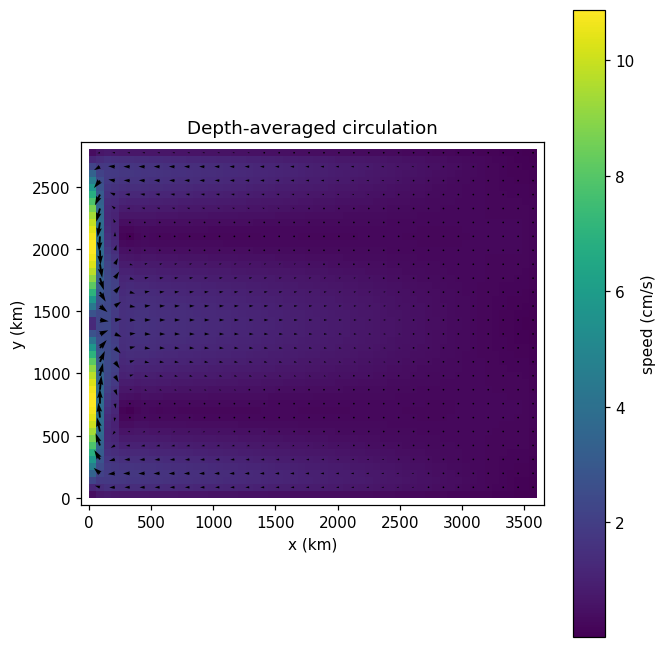

In [3]:
u, v = ds["ubar"].values, ds["vbar"].values
spd = np.hypot(u, v)
X, Y = np.meshgrid(x, y)
s = 2
fig, ax = plt.subplots(figsize=(6.2, 6))
pcm = ax.pcolormesh(x, y, spd * 100, cmap="viridis", shading="auto")
plt.colorbar(pcm, label="speed (cm/s)")
ax.quiver(X[::s, ::s], Y[::s, ::s], u[::s, ::s], v[::s, ::s], scale=1.2, width=0.004)
ax.set(xlabel="x (km)", ylabel="y (km)", title="Depth-averaged circulation")
ax.set_aspect("equal"); plt.tight_layout()
print(f"peak barotropic speed: {np.nanmax(spd)*100:.1f} cm/s")

## 3 · Spin-up of the gyre

The circulation strengthens from rest as the wind stress works on the basin.

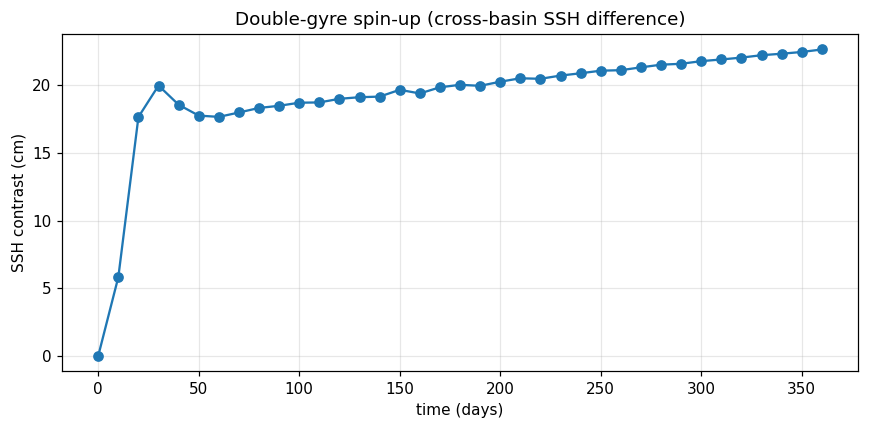

In [4]:
ssh_amp = (ds["zeta"].max(dim=["eta_rho", "xi_rho"])
           - ds["zeta"].min(dim=["eta_rho", "xi_rho"])).values * 100
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(days, ssh_amp, "o-", color="C0")
ax.set(xlabel="time (days)", ylabel="SSH contrast (cm)",
       title="Double-gyre spin-up (cross-basin SSH difference)")
ax.grid(alpha=0.3); plt.tight_layout()

---
### Reproduce / extend
- The robust recipe is `create_config.bash` → set `BASIN` in `cppdefs.h` →
  `jobcomp` (`gmake -r`) → `LC_ALL=C ./croco croco.in`.
- For a real-data regional run with AGRIF nesting (Sunda Strait), see the CROCO
  guide §15 and §17b. CROCO history files share ROMS's variable layout, so
  [`roms_croco_output.ipynb`](roms_croco_output.ipynb) opens a regional
  `croco_his.nc` directly.
- Other CROCO test cases: `CANYON`, `GRAV_ADJ`, `INTERNAL`, `VORTEX`.